In [1]:
# Code created by Pablo Cárdenas R., pablocarderam@gmail.com
# Much of this code draws from the examples outlined by MalariaGEN:
# https://malariagen.github.io/parasite-data/pf8/Data_access.html

In [2]:
# Install malariagen package
!pip install -q --no-warn-conflicts malariagen_data

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.8/215.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
sns.set_context("talk")
cbPalette = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999"]

import joblib as jl
import malariagen_data

In [4]:
# load malariagen package and metadata
pf8 = malariagen_data.Pf8()

pf8_metadata = pf8.sample_metadata()
regions = {
    'Mauritania':'West Africa', 'Gambia':'West Africa', 'Guinea':'Central Africa', 'Kenya':'East Africa', 'Thailand':'Southeast Asia and Pacific',
    'Tanzania':'East Africa', 'Ghana':'West Africa', 'Cambodia':'Southeast Asia and Pacific', 'Indonesia':'Southeast Asia and Pacific', 'Burkina Faso':'West Africa',
    'Mali':'West Africa', 'Papua New Guinea':'Southeast Asia and Pacific', 'Peru':'South America', 'Bangladesh':'South Asia', 'Malawi':'Central Africa',
    'Vietnam':'Southeast Asia and Pacific', 'Colombia':'South America', 'Venezuela':'South America', 'Uganda':'Central Africa', 'Myanmar':'Southeast Asia and Pacific', 'Laos':'Southeast Asia and Pacific',
    'Democratic Republic of the Congo':'Central Africa', 'Nigeria':'West Africa', 'Madagascar':'East Africa',
    'Cameroon':'West Africa', "Côte d'Ivoire":'West Africa', 'Ethiopia':'East Africa', 'Benin':'West Africa', 'Senegal':'West Africa',
    'Gabon':'Central Africa', 'India':'South Asia', 'Sudan':'East Africa', 'Mozambique':'East Africa'
}
pf8_metadata['Region'] = pf8_metadata['Country'].map(regions)

In [5]:
# Utility functions:

"""
Returns the reverse complement of a sequence
"""
def revComp(seq):
    revSeq = seq[::-1]; # reverse seq

    # replace nucleotides, conserve case
    revSeq = revSeq.replace("A", "1");
    revSeq = revSeq.replace("T", "2");
    revSeq = revSeq.replace("G", "3");
    revSeq = revSeq.replace("C", "4");

    revSeq = revSeq.replace("2", "A");
    revSeq = revSeq.replace("1", "T");
    revSeq = revSeq.replace("4", "G");
    revSeq = revSeq.replace("3", "C");

    revSeq = revSeq.replace("a", "1");
    revSeq = revSeq.replace("t", "2");
    revSeq = revSeq.replace("g", "3");
    revSeq = revSeq.replace("c", "4");

    revSeq = revSeq.replace("2", "a");
    revSeq = revSeq.replace("1", "t");
    revSeq = revSeq.replace("4", "g");
    revSeq = revSeq.replace("3", "c");

    return revSeq;

"""
Transcribes DNA to RNA
"""
def transcribe(dna):
    rna = dna.replace("T", "U");
    rna = rna.replace("t", "u");
    return rna;

"""
Returns genetic code dictionary. Stop codons are "*"
"""
def geneticCode():
    code = {'CGA':'R','UUU':'F','UUC':'F',
      'UUA':'L','UUG':'L','UCU':'S',
      'UCC':'S','UCA':'S','UCG':'S',
      'UAU':'Y','UAC':'Y','UAA':'*',
      'UAG':'*','UGU':'C','UGC':'C',
      'UGA':'*','UGG':'W','CUU':'L',
      'CUC':'L','CUA':'L','CUG':'L',
      'CCU':'P','CCC':'P','CCA':'P',
      'CCG':'P','CAU':'H','CAC':'H',
      'CAA':'Q','CAG':'Q','CGU':'R',
      'CGC':'R','AGA':'R','CGG':'R',
      'AUU':'I','AUC':'I','AUA':'I',
      'AUG':'M','ACU':'T','ACC':'T',
      'ACA':'T','ACG':'T','AAU':'N',
      'AAC':'N','AAA':'K','AAG':'K',
      'AGU':'S','AGC':'S','GGA':'G',
      'AGG':'R','GUU':'V','GUC':'V',
      'GUA':'V','GUG':'V','GCU':'A',
      'GCC':'A','GCA':'A','GCG':'A',
      'GAU':'D','GAC':'D','GAA':'E',
      'GAG':'E','GGU':'G','GGC':'G',
      'GGG':'G'
      };
    return code;

"""
Translates RNA to protein (takes rna string, returns peptide string).
"""
def translate(pSeq):
    seq = transcribe(pSeq.upper()); # everything to uppercase
    code = geneticCode(); # Stores genetic code
    pep = ""; # stores peptide sequence
    i = 0; # position on RNA sequence
    while i < len(seq): # for every codon
        codon = seq[i:(i+3)]; # get current codon
        if len(codon) == 3:
            aa = code[codon]; # get aminoacid
            pep = pep + aa; # add residue to peptide
#             if (aa != "*"): # if not a stop codon
            i = i+3; # next codon
#             else: # if codon is stop
#                 i = len(seq); # stop loop
        else:
            i = len(seq); # stop loop
    return pep;

In [6]:
# Define genomic location of interest for CSP repeats:
csp_chrom = 'Pf3D7_03_v3'
lower_lim_csp = 221323
upper_lim_csp = 222516
lower_lim_repeats = lower_lim_csp + 124*3
upper_lim_repeats = upper_lim_csp - 101*3

In [7]:
# Check sequence of reference genome to confirm CSP repeats
repeats_dna = ''.join(list(pf8.genome_sequence(region=csp_chrom+':'+str(lower_lim_repeats)+'-'+str(upper_lim_repeats)).compute().astype(str)))
repeats_pro = translate(revComp(repeats_dna))
repeats_pro

'PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNVDPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNANPNK'

In [8]:
# Get variant calls, show data structure
vc=pf8.variant_calls(extended=False)
csp = vc.isel(variants=((vc.variant_chrom==csp_chrom)&(vc.variant_position>lower_lim_repeats)&(vc.variant_position<upper_lim_repeats)).compute())
csp

<xarray.Dataset> Size: 129MB
Dimensions:              (variants: 241, alleles: 7, samples: 33325, ploidy: 2)
Coordinates:
    variant_position     (variants) int32 964B dask.array<chunksize=(241,), meta=np.ndarray>
    variant_chrom        (variants) object 2kB dask.array<chunksize=(241,), meta=np.ndarray>
    sample_id            (samples) object 267kB dask.array<chunksize=(16663,), meta=np.ndarray>
Dimensions without coordinates: variants, alleles, samples, ploidy
Data variables:
    variant_allele       (variants, alleles) object 13kB dask.array<chunksize=(241, 1), meta=np.ndarray>
    variant_filter_pass  (variants) bool 241B dask.array<chunksize=(241,), meta=np.ndarray>
    variant_is_snp       (variants) bool 241B dask.array<chunksize=(241,), meta=np.ndarray>
    variant_numalt       (variants) int32 964B dask.array<chunksize=(241,), meta=np.ndarray>
    variant_CDS          (variants) bool 241B dask.array<chunksize=(241,), meta=np.ndarray>
    call_genotype        (variants, samples, ploidy) int8 16MB dask.array<chunksize=(241, 100, 2), meta=np.ndarray>
    call_AD              (variants, samples, alleles) int16 112MB dask.array<chunksize=(241, 100, 7), meta=np.ndarray>

In [9]:
# Genotype data structure
csp_gt = csp["call_genotype"].data
csp_gt

dask.array<getitem, shape=(241, 33325, 2), dtype=int8, chunksize=(241, 100, 2), chunktype=numpy.ndarray>

In [10]:
# Access data from genomic position (takes a couple of minutes to run)
genotypes = csp["call_genotype"].data.compute()
    # contains actual DNA sequence info
positions = csp.variant_position.compute()
    # contains positions of variants
alleles = csp.variant_allele.compute()
    # contains ID numbers of variants

In [11]:
# We now extract the protein sequences to create a database of CSP repeat region
# sequences. Takes a few minutes

seqs = pd.DataFrame([[repeats_dna, translate( revComp(repeats_dna) )]])
  # this will contain our protein sequences
proteins = [] # this will contain our protein sequences

'''
Reconstruct DNA and protein sequence for the genomic context provided
'''
def processSample(
        ploidy,sample,reference=repeats_dna,lower_lim_region=lower_lim_repeats,
        genotypes=genotypes,positions=positions,alleles=alleles):
    seq = reference[0]
        # we start with reference genome CSP repeat seq and modify according
        # to alleles, this will be our reconstructed sequence for this sample
    prev_var_pos = 0 # this stores the index of the previous variant locus
    for variant in range(1,genotypes.shape[0]):
            # for each variant locus,
        var_position = int(positions[variant]) - lower_lim_region
            # obtain genomic position of this variant
        allele_i = genotypes[variant,sample,ploidy]
            # obtain allele number ID at this position
        if allele_i > 0:
                # if allele is not WT,
            allele = str(alleles[variant][ allele_i-1 ].data)
                # obtain sequence of allelic variant
        else: # if allele is WT, then save the WT allele sequence
            allele = reference[var_position]

        if allele == '*': # if allele is a deletion, store as such
            allele = ''

        seq = seq + reference[prev_var_pos+1:var_position] + allele
            # add reference sequence since last allelic position plus new
            # allele sequence to the current sequence being reconstructed
        prev_var_pos = var_position
            # save the current allelic position as the new previous position

    # When done adding all alleles,
    seq = seq + reference[prev_var_pos+1:] # add remaining reference genome

    pep = translate( revComp(seq) ) # protein sequence

    return [seq, pep] # return dna, protein


for ploidy in range(genotypes.shape[2]):
      # for the top two majority alleles (denoted as "ploidy" in the data as a
      # holdover from human sequences, even though that doesn't make sense for
      # Plasmodium)
    new_seqs = jl.Parallel(jl.cpu_count(), verbose=7)(
        jl.delayed(processSample)(ploidy,sample) for sample in range(genotypes.shape[1])
        ) # parallelize sequence reconstruction across all sequences
    seqs = pd.concat([seqs,pd.DataFrame(new_seqs)])
        # concatenate sequences into a dataframe


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    1.5s
[Parallel(n_jobs=2)]: Done  58 tasks      | elapsed:    2.2s
[Parallel(n_jobs=2)]: Done 378 tasks      | elapsed:    6.1s
[Parallel(n_jobs=2)]: Done 826 tasks      | elapsed:   12.8s
[Parallel(n_jobs=2)]: Done 1402 tasks      | elapsed:   20.1s
[Parallel(n_jobs=2)]: Done 2106 tasks      | elapsed:   30.8s
[Parallel(n_jobs=2)]: Done 2938 tasks      | elapsed:   42.0s
[Parallel(n_jobs=2)]: Done 3898 tasks      | elapsed:   54.6s
[Parallel(n_jobs=2)]: Done 4986 tasks      | elapsed:  1.2min
[Parallel(n_jobs=2)]: Done 6202 tasks      | elapsed:  1.4min
[Parallel(n_jobs=2)]: Done 7546 tasks      | elapsed:  1.8min
[Parallel(n_jobs=2)]: Done 9018 tasks      | elapsed:  2.1min
[Parallel(n_jobs=2)]: Done 10618 tasks      | elapsed:  2.5min
[Parallel(n_jobs=2)]: Done 12346 tasks      | elapsed:  2.9min
[Parallel(n_jobs=2)]: Done 14202 tasks      | elapsed:  3.3

In [18]:
# Now we analyze the numbers and types of repeats

rep_seq = 'NPNV'
    # the key repeat sequence being studied the minor repeat
    # (actual epitope is NPNV)
threepeat_seq = 'NVDPNANPNVDPNANPNVDP'
    # The most common motif the minor repeat is found in

# We build a dataframe for all the info
dat = pd.DataFrame()
dat['Sample'] = np.tile(csp.sample_id.compute(),2)
dat['Ploidy'] = [0] * len(csp.sample_id.compute()) + [1] * len(csp.sample_id.compute())
    # Ploidy refers to first or second most common alleles in sample,
    # as explained above
dat['Genomic_DNA'] = list(seqs[0])[1:]
dat['Protein'] = list(seqs[1])[1:]
dat['Num_NANP'] = dat['Protein'].str.count('NANP')
dat['Num_'+rep_seq] = dat['Protein'].str.count(rep_seq)

# Split protein sequences by the repeat sequence
spl = dat['Protein'].str.split(rep_seq)

'''
Minimum distance in aa between repeats when given the list of sequences between
repeats
'''
def minRepeatDist(frags):
    if len(frags) > 2:
        return min( [ len(frag) for frag in frags[1:-1] ] )
    else:
        return np.nan

'''
Mean distance in aa between repeats when given the list of sequences between
repeats
'''
def meanRepeatDist(frags):
    if len(frags) > 2:
        return np.array( [ len(frag) for frag in frags[1:-1] ] ).mean()
    else:
        return np.nan

'''
Number of instances in which two repeats are separated by a specific number of
aa when given the list of sequences between repeats
'''
def numAtDistance(frags,d=4):
    if len(frags) > 2:
        return np.count_nonzero( np.array( [ len(frag) for frag in frags[1:-1] ] ) == d )
    else:
        return np.nan

# Compute values
dat['Min_dist_between_'+rep_seq] = spl.apply( minRepeatDist )
dat['Mean_dist_between_'+rep_seq] = spl.apply( meanRepeatDist )
dat['Num_4distance'] = spl.apply( numAtDistance )
dat['Num_3peat'] = dat['Protein'].str.count(threepeat_seq)

# Obtain sample metadata
pf8_metadata.index=pf8_metadata['Sample']
dat.index=dat['Sample']

dat = dat.join(pf8_metadata.drop(columns=['Sample']))

dat = dat.reset_index(drop=True)
dat = dat.drop_duplicates(['Sample', 'Genomic_DNA'])

dat.to_csv('csp_repeat_analysis_db.csv',index=False)
dat

,Sample,Ploidy,Genomic_DNA,Protein,Num_NANP,Num_NPNV,Min_dist_between_NPNV,Mean_dist_between_NPNV,Num_4distance,Num_3peat,...,Year,ENA,All samples same case,Population,% callable,QC pass,Exclusion reason,Sample type,Sample was in Pf7,Region
0,FP0008-C,0,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,40,4,4.0,25.333333,2.0,1,...,2014.0,ERR1081237,FP0008-C,AF-W,82.48,True,Analysis_set,gDNA,True,West Africa
1,FP0009-C,0,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,40,4,4.0,25.333333,2.0,1,...,2014.0,ERR1081238,FP0009-C,AF-W,88.95,True,Analysis_set,gDNA,True,West Africa
2,FP0010-CW,0,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,38,4,4.0,25.333333,2.0,1,...,2014.0,ERR2889621,FP0010-CW,AF-W,87.01,True,Analysis_set,sWGA,True,West Africa
3,FP0011-CW,0,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,11,3,4.0,4.000000,2.0,1,...,2014.0,ERR2889624,FP0011-CW,AF-W,86.95,True,Analysis_set,sWGA,True,West Africa
4,FP0012-CW,0,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,40,4,4.0,25.333333,2.0,1,...,2014.0,ERR2889627,FP0012-CW,AF-W,89.86,True,Analysis_set,sWGA,True,West Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65943,SPT91360,1,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,37,4,4.0,25.333333,2.0,1,...,2020.0,ERR10892965,SPT91360,AF-W,77.69,True,Analysis_set,sWGA,False,West Africa
66071,SPT91492,1,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,53,7,4.0,24.000000,3.0,1,...,2020.0,ERR10893209,SPT91492,AF-W,17.80,False,Low_coverage,sWGA,False,West Africa
66104,SPT91525,1,TTTATTAGGGTTTGCATTTGGGTTTGCATTTGGGTTTGCATTTGGA...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,41,4,4.0,25.333333,2.0,1,...,2020.0,ERR10893218,SPT91525,AF-W,79.23,True,Analysis_set,sWGA,False,West Africa
66123,SPT91544,1,TTTATTAGGATTTGCATTGGGGTTTGCATTTGGGTTTGCATTTGGG...,PDPNANPNVDPNANPNVDPNANPNVDPNANPNANPNANPNANPNAN...,14,3,4.0,4.000000,2.0,1,...,2020.0,ERR10893237,SPT91544,AF-W,82.10,True,Analysis_set,sWGA,False,West Africa


In [19]:
# Load saved data to avoid recomputing everything when rerunning analysis
# dat = pd.read_csv('csp_repeat_analysis_db.csv')

/tmp/ipykernel_941/1617255080.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=0, ha='right', fontsize=22, )
/tmp/ipykernel_941/1617255080.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_yticklabels(axs[1].get_yticklabels(), rotation=0, ha='right', fontsize=22, )



Total sequences breakdown:
Region
Africa                          10383.0
Americas                          222.0
South and \nWest Asia            1219.0
Southeast Asia \nand Pacific     6676.0
dtype: float64


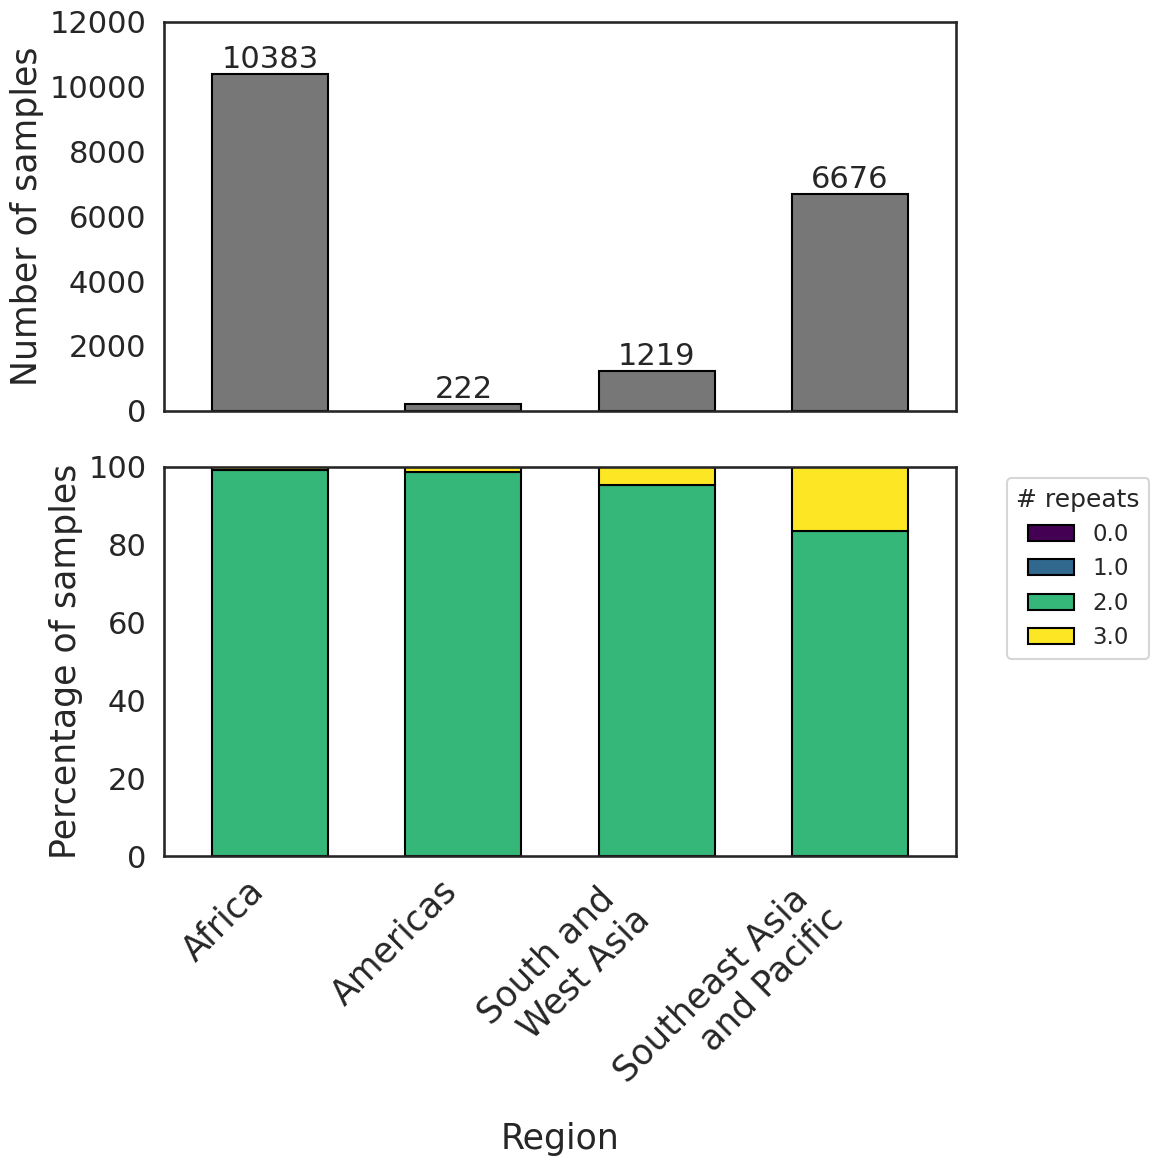


Percentage breakdown:
Num_4distance                 0.0   1.0    2.0    3.0
Region                                               
Africa                        0.0  0.03  99.12   0.85
Americas                      0.0  0.00  98.65   1.35
South and \nWest Asia         0.0  0.00  95.47   4.53
Southeast Asia \nand Pacific  0.0  0.00  83.64  16.36


In [21]:
# Compute percentage breakdowns by number of repeats separated by 4 aa
# and make plots

# Plot 1

# Mark samples with more than one allele as heterozygous (these are actually
# complex infections)
dat['Heterozygous'] = dat['Sample'].isin(dat.loc[(dat['Ploidy']==1),'Sample'])

# Filter out heterozygous samples and samples failing MalariaGEN QC
# also replace region names with macro regions
df = dat.loc[(dat['QC pass'])&~(dat['Heterozygous']),].replace('West Africa','Africa').replace('East Africa','Africa').replace('Central Africa','Africa').replace('West Asia','South and \nWest Asia').replace('South Asia','South and \nWest Asia').replace('Pacific','Southeast Asia \nand Pacific').replace('Southeast Asia','Southeast Asia \nand Pacific').replace('Southeast Asia and Pacific','Southeast Asia \nand Pacific').replace('Southeast Asia','Southeast Asia \nand Pacific').replace('South America','Americas')

# Count number of samples at every given number of repeats separated by 4 aa,
# for every region
df = df.groupby(["Region","Num_4distance"]).apply("count").reset_index()

# Calculate percentage breakdown for each region
df_pivot = df.pivot_table(
    index='Region',
    columns='Num_4distance',
    values='Sample',
    fill_value=0
)

# Calculate sum
df_pct = df_pivot.sum(axis=1)

# Create the stacked bar chart
f, axs = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
axs[0] = plt.subplot(211)
p = axs[0].bar(df_pivot.index, df_pct, edgecolor='black', width=0.6, color="#777777")

# Customize the chart
axs[0].set_xlabel('', fontsize=25)
axs[0].set_ylabel('Number of samples', fontsize=25)
axs[0].set_ylim(0, 12000)
plt.tick_params('x', labelbottom=False)
axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=0, ha='right', fontsize=22, )
axs[0].bar_label(p, fontsize=22, )

print("\nTotal sequences breakdown:")
print(df_pct.round(2))

# Plot 2

df_pivot[0.0]=0
    # zero samples with zero repeats at a distance of 4 (makes no sense)

df_pivot = df_pivot[np.linspace(0,8,9)]

# sum all samples with four or more repeats at a distance of 4
df_pivot[4.0] = df_pivot.iloc[:, 3:].sum(axis=1)
df_pivot = df_pivot.drop(df_pivot.columns[[4,5,6,7,8]], axis=1)

# Calculate percentages
df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

# Create the stacked bar chart
axs[1] = plt.subplot(212)
df_pct.plot(kind='bar', stacked=True, ax=axs[1], colormap='viridis', edgecolor='black', width=0.6)

# Customize the chart
axs[1].set_xlabel('Region', fontsize=25)
axs[1].set_ylabel('Percentage of samples', fontsize=25, )
axs[1].legend(title='# repeats', bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_ylim(0, 100)
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right', fontsize=25, )
axs[1].set_yticklabels(axs[1].get_yticklabels(), rotation=0, ha='right', fontsize=22, )

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/stacked_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPercentage breakdown:")
print(df_pct.round(2))